### Uber Supply Demand Gap Exploratory Data Anlysis Project 

# **Project Name**    -  Uber EDA Project



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - Jahnavi Krishna

# **Project Summary -**

**Uber Technologies, Inc. is an American multinational transportation company that provides ride-hailing services, courier services, food delivery, and freight transport. It is headquartered in San Francisco, California, and operates in approximately 70 countries and 15,000 cities worldwide.
It is the largest ridesharing company worldwide with over 150 million monthly active users and 6 million active drivers and couriers. It coordinates an average of 28 million trips per day, and has coordinated 47 billion trips since its inception in 2010.
In 2023, the company had a take rate (revenue as a percentage of gross bookings) of 28.7% for mobility services and 18.3% for food delivery.
We have given a dataset through which we have to analyze the demand and supply gap for Uber Company by doing EDA operation on given dataset.**

# **GitHub Link -**

**https://github.com/Jahnavi-art504**

# **Problem Statement**


**We have given a dataset on which we have to do EDA operation to analyze and solve problems for the Uber Demand Gap through it ?**

#### **Define Your Business Objective?**

**The following are the business objective for this project:-**

1) To find the reason of cancellation of cab rides by drivers.
2) To find the solution to increase the transparency of cab ride fairs.
3) To find the permanent solution to customer problems so that to increase customer engagement and customer statisfaction rate.
4) To find various method to increase customer engagement to use this app over other apps and ultimately increase profits for the organization.
5) To find solution to increase safety of cab rides specially in night time. 

## ***1. Know Your Data***

### Import Libraries

In [27]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
import statsmodels as stat
import geopandas as geo
import missingno as ms

### Dataset Loading

In [13]:
# Load Dataset
md = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [15]:
# Dataset First Look
md.head(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [17]:
# Dataset tail look
md.tail(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN
6744,6753,Airport,NaN,No Cars Available,15-07-2016 23:55:03,NaN


### Dataset Rows & Columns count

In [19]:
# Dataset Rows & Columns count
md.shape

(6745, 6)

### Dataset Information

In [21]:
# Dataset Info
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [23]:
# Dataset Duplicate Value Count
# Check for duplicate values
duplicates = md.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    6745
Name: count, dtype: int64


#### Missing Values/Null Values

In [25]:
# Missing Values/Null Values Count
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

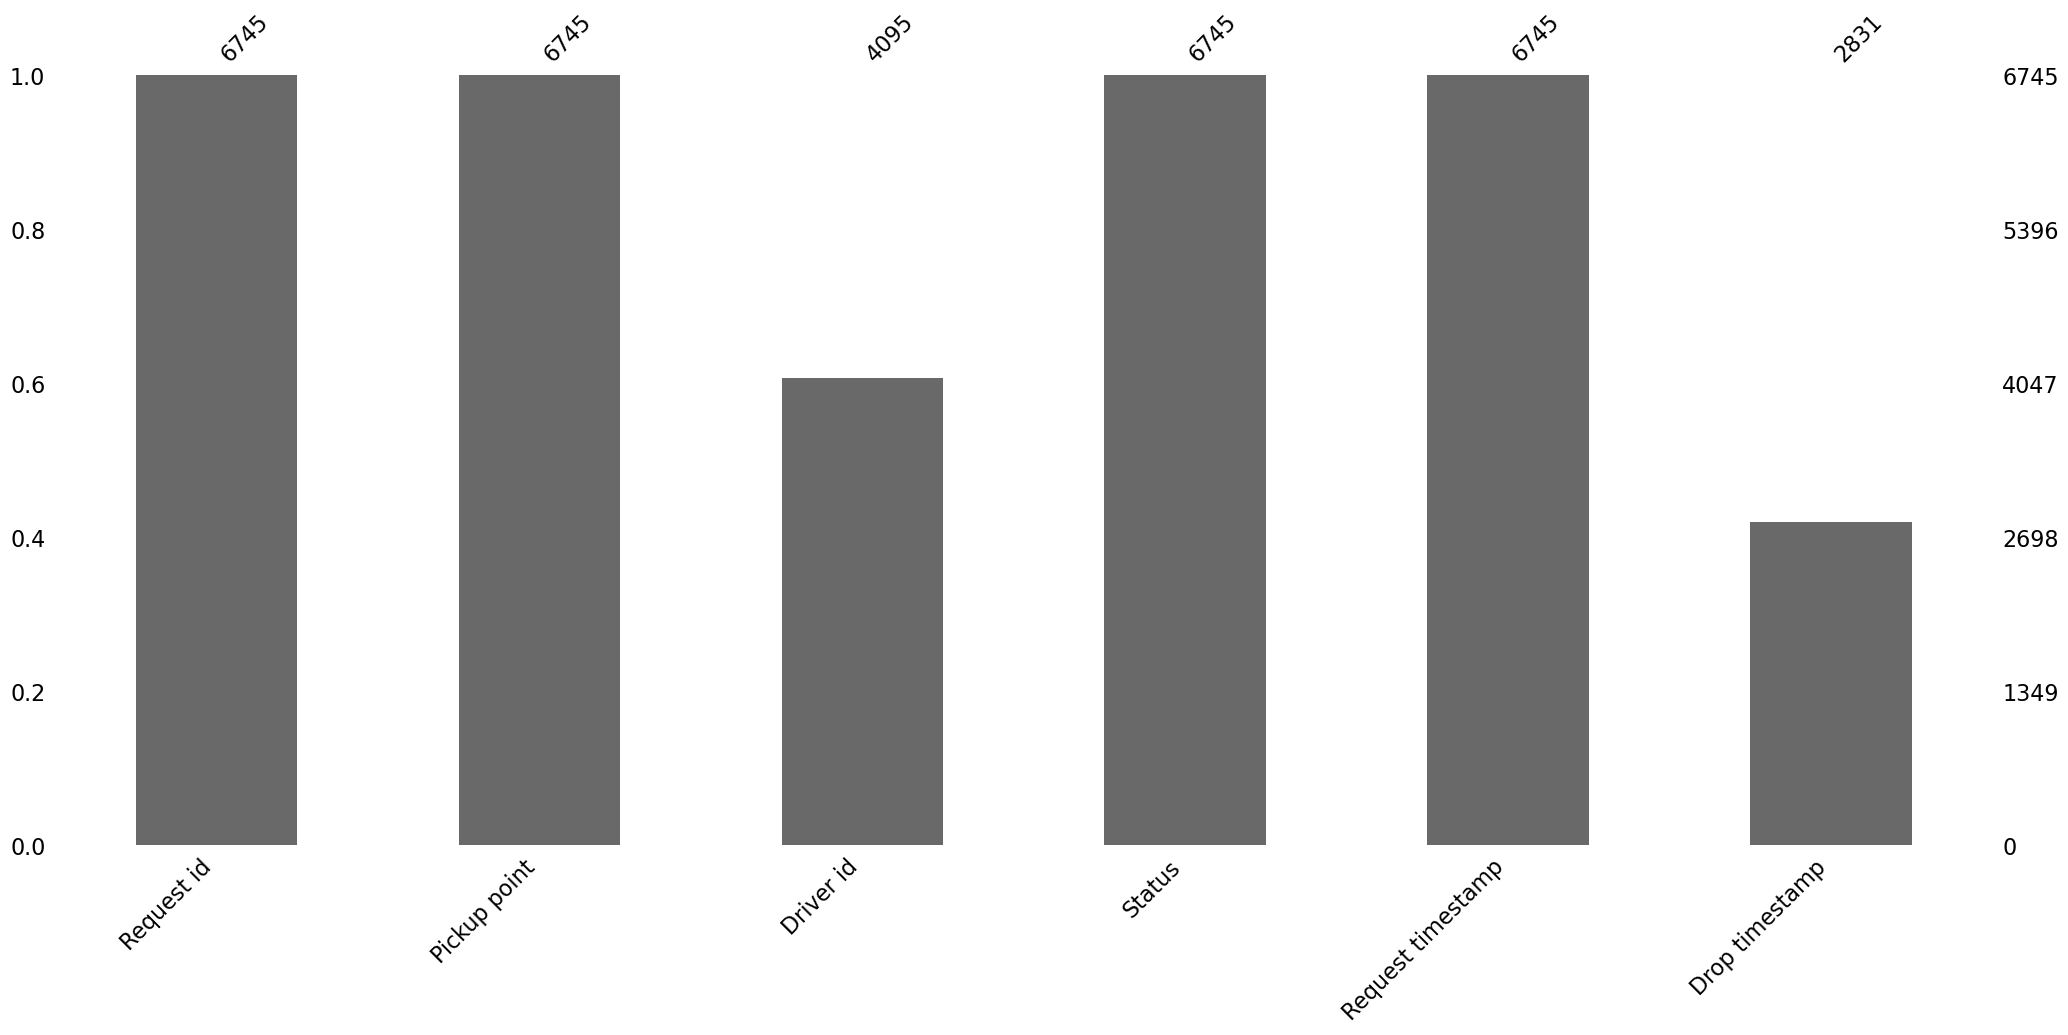

In [29]:
# Visualizing the missing values
ms.bar(md)
plt.show()

### What did you know about your dataset?

**The following are the major points about the dataset:-**

1) The dataset contains 6 columns and 6745 rows.
2) There are no duplicate values in the dataset.

**Follwoing 2 columns are having some missing values:-**

Driver id-----2650

Drop timestamp-----3914

## ***2. Understanding Your Variables***

In [33]:
# Dataset Columns
md.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [35]:
# Dataset Describe
md.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

**The following are the variables with their description:-**

**Column names---------------------------Description**

1) Request id-------------------Customer Unique id who requested for the cab service through app.
2) Pickup point-----------------Pickup location to pickup the customer.
3) Driver id--------------------Unique Id of driver who is driving the cab.
4) Status-----------------------status of trip that if it got completed, cancelled or no cabs are available.
5) Request timestamp------------Request time and date when the customer requested for the cab service.
6) Drop timestamp---------------Drop time and date when the customer is dropped to their respective location.


The above are the descriptions for the variables present in the dataset.

### Check Unique Values for each variable.

In [37]:
# Check Unique Values for each variable.
for x in md.columns:
    print(f"{x} - {md[x].nunique()}") 

Request id - 6745
Pickup point - 2
Driver id - 300
Status - 3
Request timestamp - 5618
Drop timestamp - 2598


## 3. ***Data Wrangling***

### Data Wrangling Code

In [41]:
# Write your code to make your dataset analysis ready.
# checking for the null values in the dataset
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [43]:
md.fillna({"Driver id": "Not Available"},inplace=True)

In [45]:
md.fillna({"Drop timestamp": "Not Available"},inplace=True)

In [47]:
# checking that the missing values are present or removed
md.isnull().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
dtype: int64

### What all manipulations have you done and insights you found?

**The following manipulation we have done to our dataset:-**

1) As there were no duplicates so no issue of removing it.
2) There are total 2 columns having missing values which we replaced with Not Available value.

Driver id-----2650

Drop timestamp-----3914

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

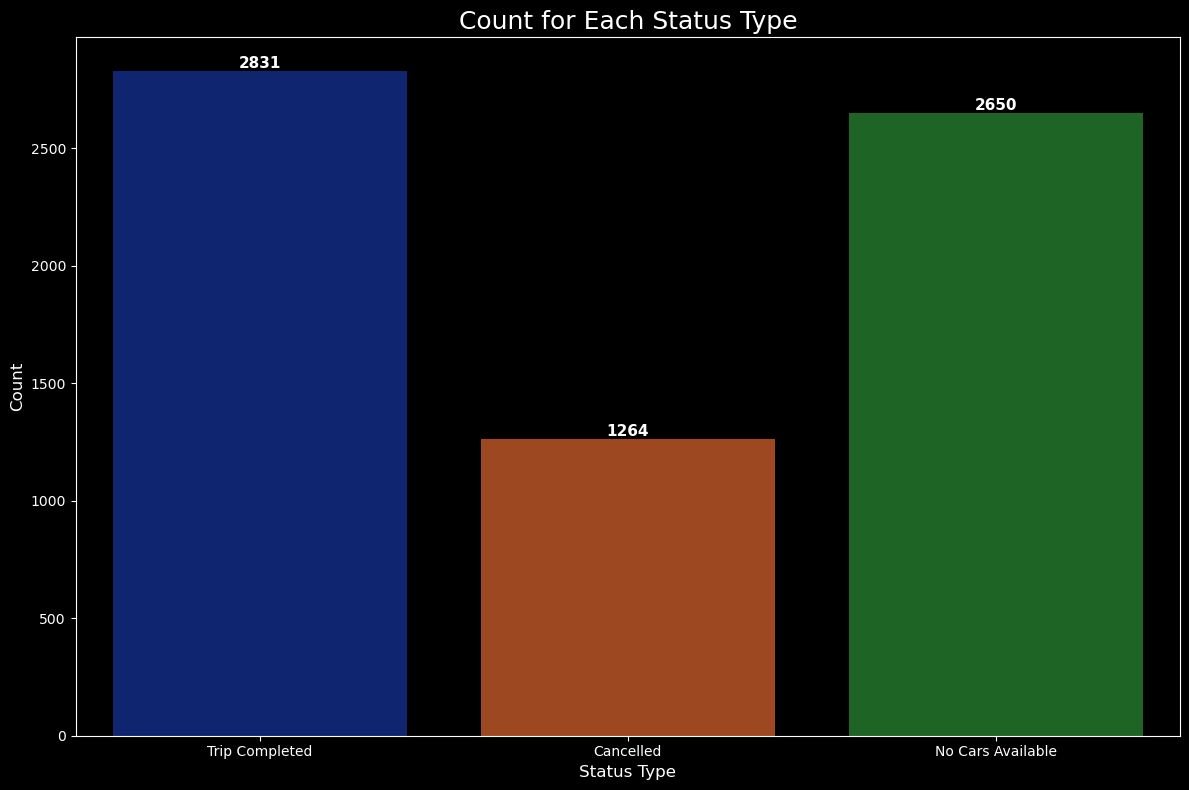

In [63]:
# Chart - 1 visualization code
plt.style.use('dark_background')
md.columns = md.columns.str.strip()
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='Status', data=md, hue="Status", palette="dark", legend=0)
plt.title('Count for Each Status Type', fontsize=18)
plt.xlabel('Status Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',  
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above bar plot gives clear count for status type.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) Highest count is for Trip completed status which is 2831.
2) Second highest count is for No Cars Available status which is 2650.
3) Lowest count is for Cancelled status which is 1264.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that maximum cars have completed their trip but almost equal no of cars have not completed trip as they were not available at that moment, which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profits for the organisation.

#### Chart - 2

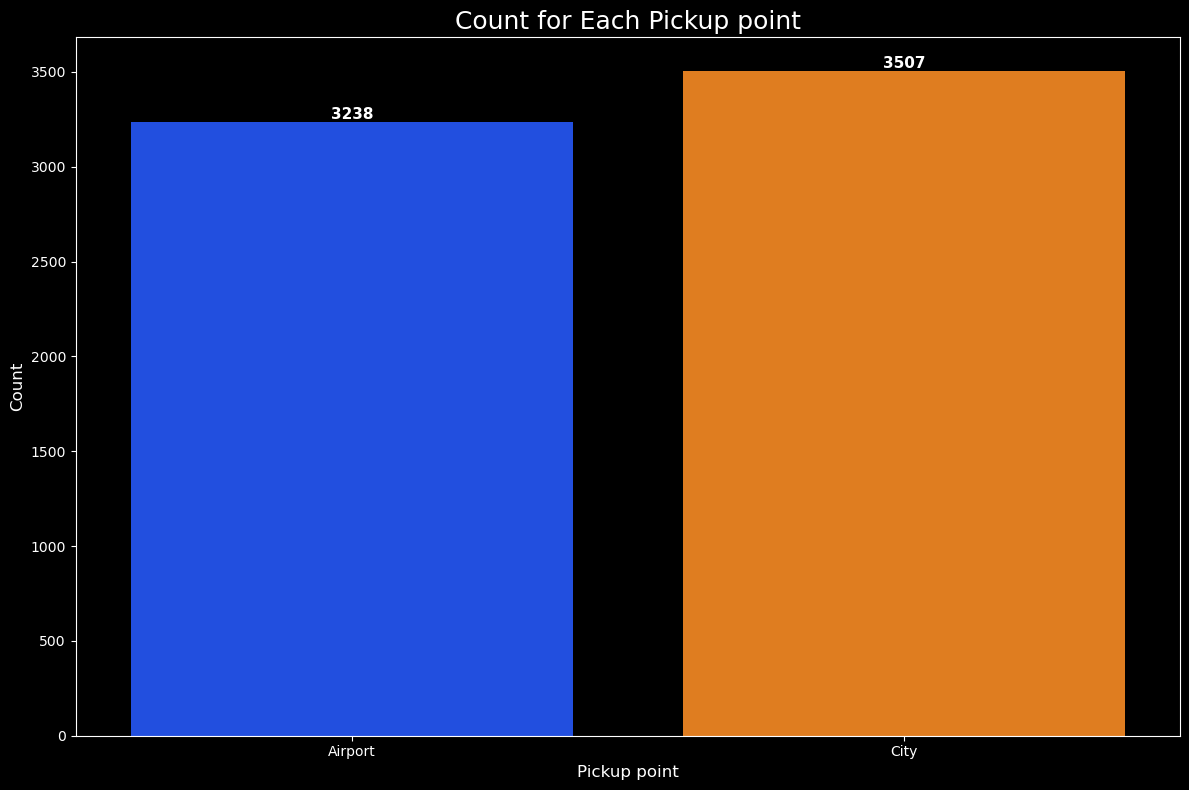

In [70]:
# Chart - 2 visualization code
plt.style.use('dark_background')
md.columns = md.columns.str.strip()
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='Pickup point', data=md, hue="Pickup point", palette="bright", legend=0)
plt.title('Count for Each Pickup point', fontsize=18)
plt.xlabel('Pickup point', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',  
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above bar plot gives clear count for pickup point.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) Highest count is for city pickup point which is 3507.
2) Lowest count is for airport pickup point which is 3238.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that people often prefer Uber services inside city commute rather than airport commute which means company can do campaigns and offer some discounts on premium uber black service if customer books it from airport to ultimately increase profits for the company.

#### Chart - 3

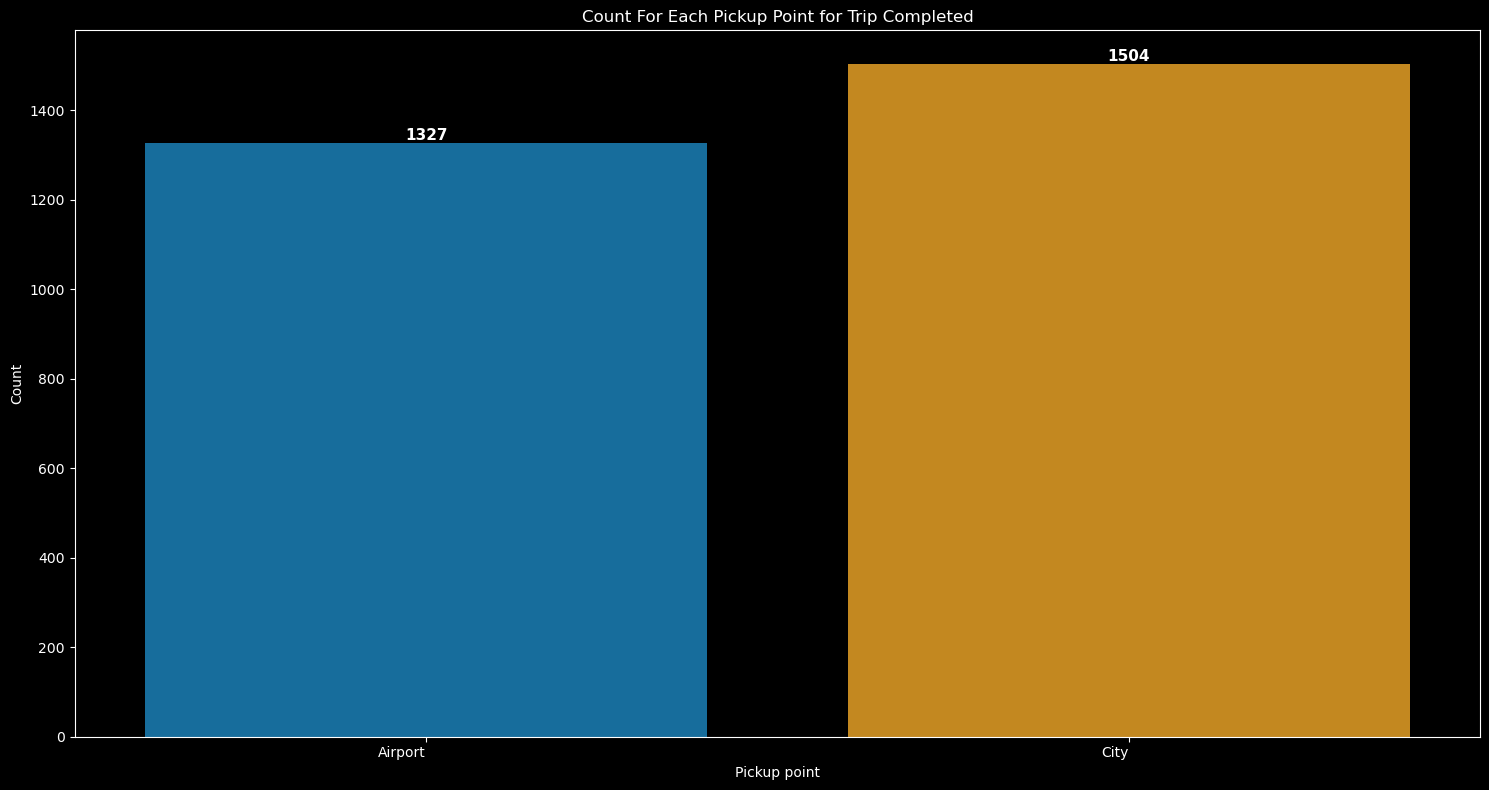

In [74]:
# Chart - 3 visualization code
plt.style.use('dark_background')
trip_c = md[md.Status=='Trip Completed'].groupby('Pickup point')['Pickup point'].count()
trip_c_1 = pd.DataFrame(trip_c)
# Rename the count column
trip_c_1.rename(columns={'Pickup point': 'count'}, inplace=True)
trip_c_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=trip_c_1 , x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")  
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for Trip Completed")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',  
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) For trip completed status the highest count is for city which is 1504.
2) For trip completed status the lowest count is for airport which is 1327.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

As per the above insights, it shows that almost equal number of count is their for trip completion status for both pickup point which is great positive sign but, company can improve a little bit for airport pickup point to increase overall cuatomer satisfaction and profits. 

#### Chart - 4

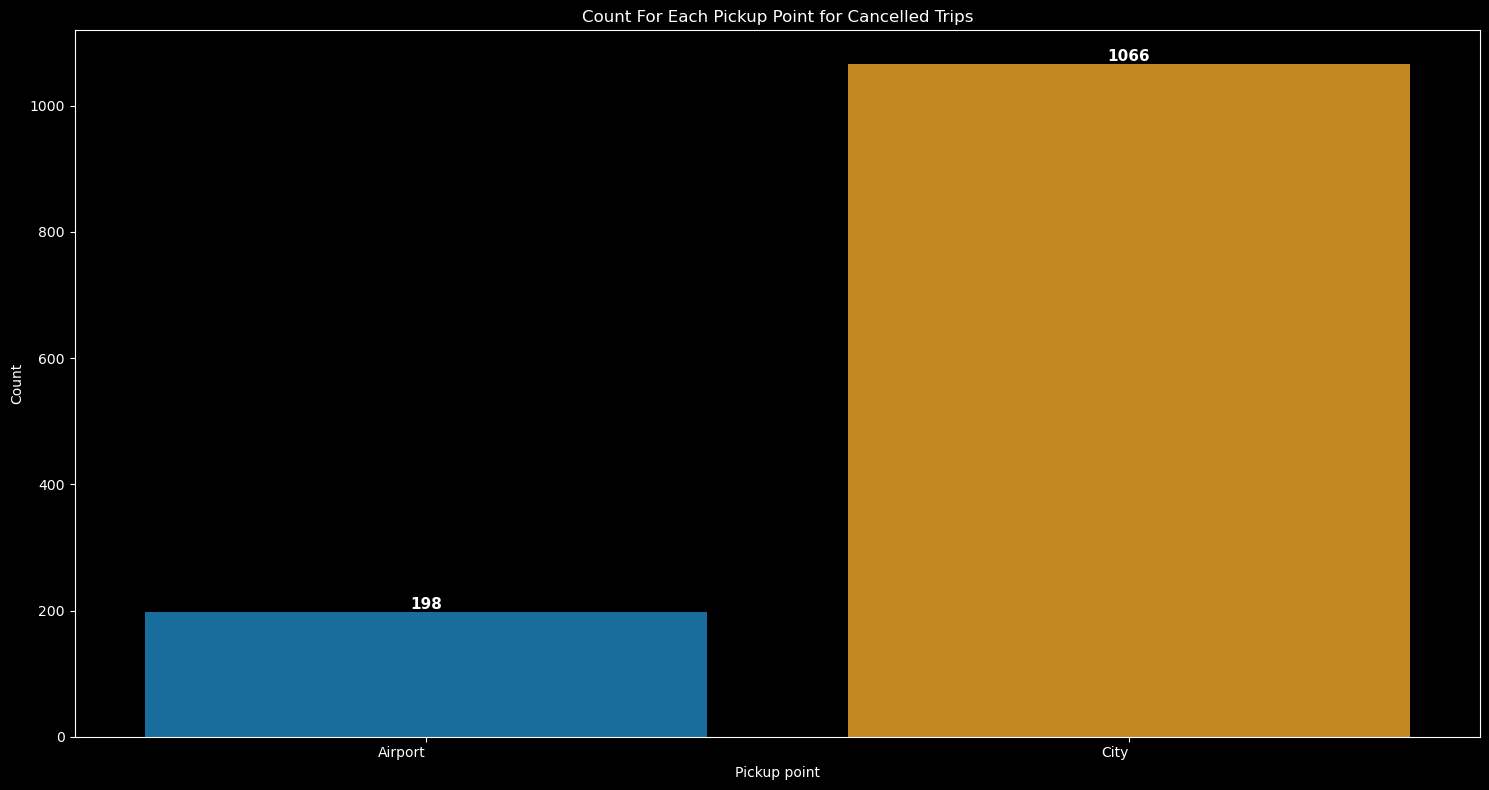

In [78]:
# Chart - 4 visualization code
plt.style.use('dark_background')
cancel = md[md.Status=='Cancelled'].groupby('Pickup point')['Pickup point'].count()
cancel_1 = pd.DataFrame(cancel)
# Rename the count column
cancel_1.rename(columns={'Pickup point': 'count'}, inplace=True)
cancel_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=cancel_1 , x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")  
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for Cancelled Trips")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',  
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) For Cancelled Trips status the highest count is for city which is 1066.
2) For Cancelled Trips status the lowest count is for airport which is 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows a very negative aspect, as we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall company reputation. 

#### Chart - 5

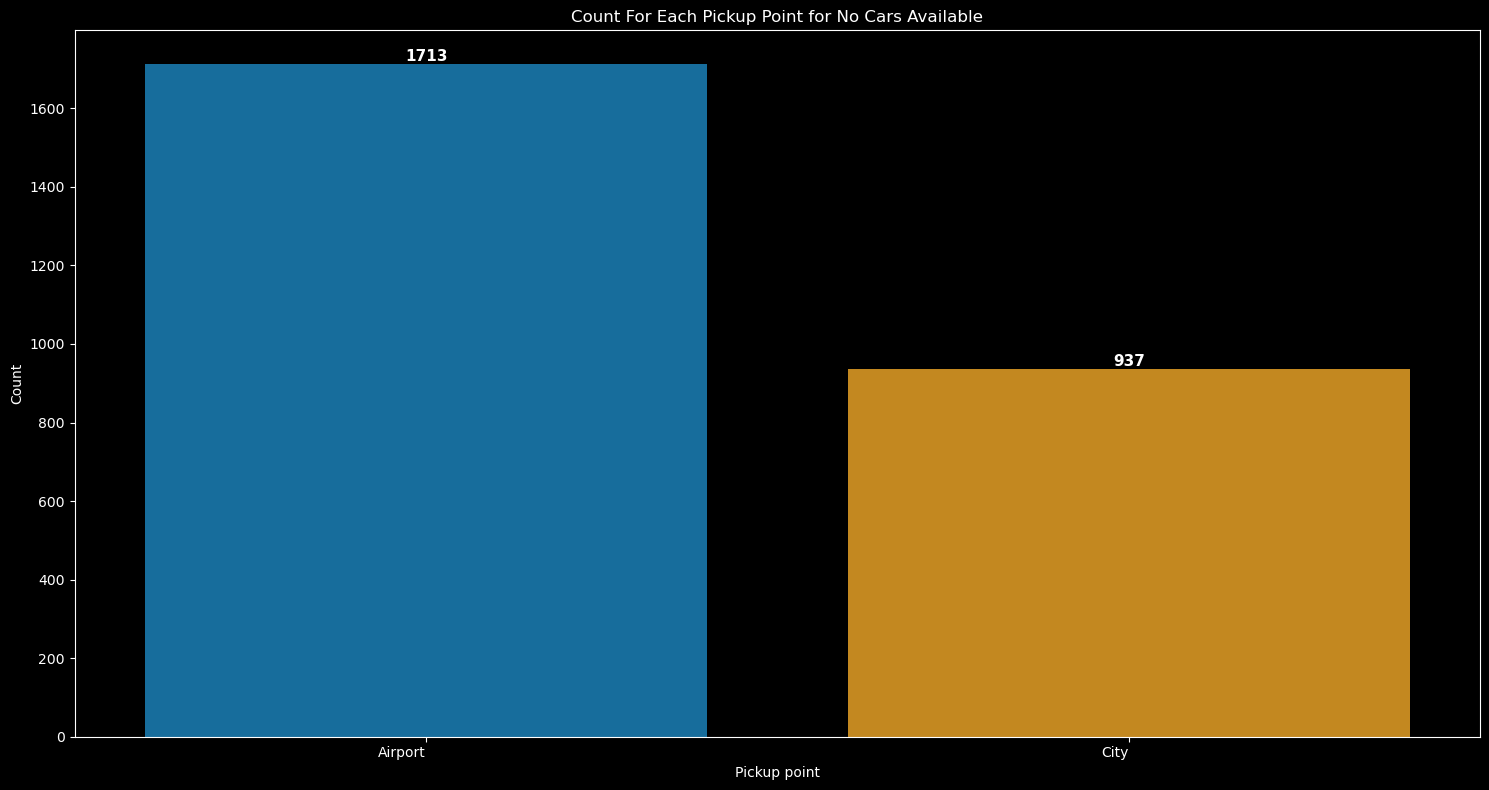

In [82]:
# Chart - 5 visualization code
plt.style.use('dark_background')
nocars = md[md.Status=='No Cars Available'].groupby('Pickup point')['Pickup point'].count()
nocars_1 = pd.DataFrame(nocars)
# Rename the count column
nocars_1.rename(columns={'Pickup point': 'count'}, inplace=True)
nocars_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=nocars_1 , x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")  
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for No Cars Available")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',  
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) For no cars available status the highest count is for airport which is 1713.
2) For no cars available status the lowest count is for city which is 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that maximum cars are not available at airport pickup point where the most of the business comes for any cab service company, so if uber wants to increase its profits it should provide more number of cars at airport so as to not miss the opportunity of earn and retain frequent flyers who commute through airport and use cab services.

#### Chart - 6

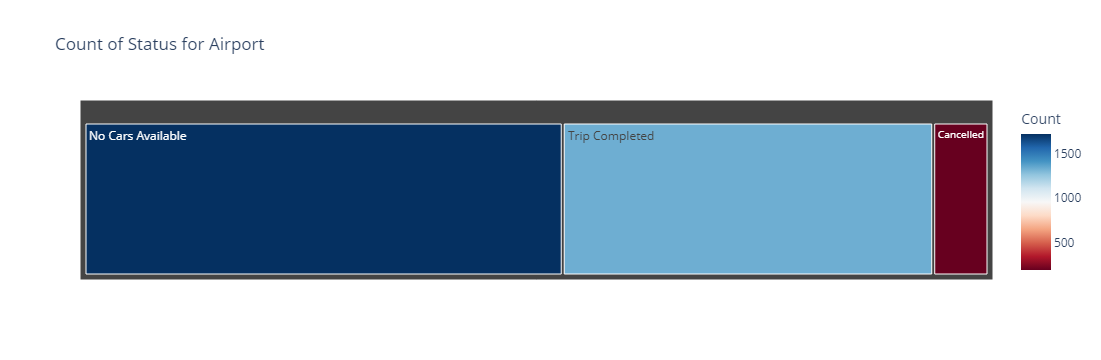

In [84]:
# Chart - 6 visualization code
plt.style.use('dark_background')

# Ensure clean column names
md.columns = md.columns.str.strip()

# Filter for Pickup point = 'Airport'
airport_df = md[md['Pickup point'].str.strip() == 'Airport']

# Group by Status and count
type_count = airport_df['Status'].value_counts().reset_index()
type_count.columns = ['Status', 'Count']

# Create the treemap
fig = px.treemap(type_count, 
                 path=['Status'], 
                 values='Count', 
                 title="Count of Status for Airport",
                 color='Count', 
                 color_continuous_scale="RdBu")

# Show the plot
fig.show()

##### 1. Why did you pick the specific chart?

The above tree map gives clear details when we hover over it and helps us to compare various variables in single tree map.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above tree map:-

1) Highest count of airport status is for No cars Available which is 1713.
2) Second highest count of airport status is for Trip Completed which is 1327.
3) Lowest count of airport status is for cancelled which is 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the airport pickup point has less available cars because of which customers are preferring other cab services, if company wants to reduce or eliminate the competition than they have to allocate more cars at airport so as to increase customer engagement and profits.

#### Chart - 7

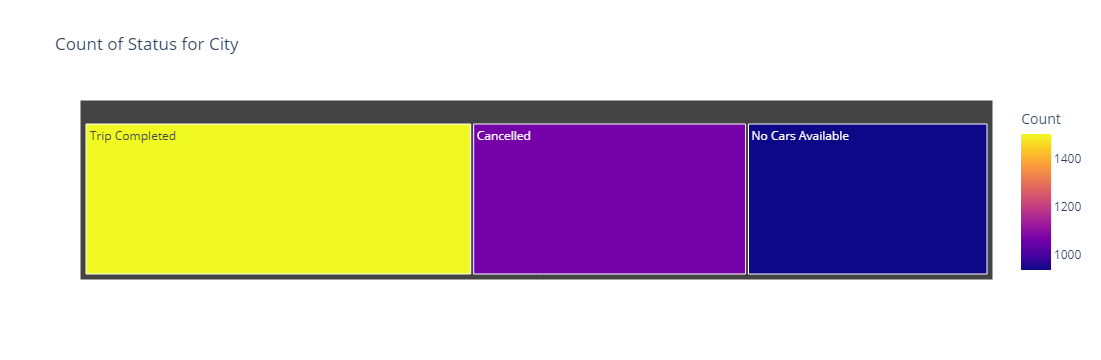

In [86]:
# Chart - 7 visualization code
plt.style.use('dark_background')

# Ensure clean column names
md.columns = md.columns.str.strip()

# Filter for Pickup point = 'Airport'
City_df = md[md['Pickup point'].str.strip() == 'City']

# Group by Status and count
City_df_count = City_df['Status'].value_counts().reset_index()
City_df_count.columns = ['Status', 'Count']

# Create the treemap
fig = px.treemap(City_df_count, 
                 path=['Status'], 
                 values='Count', 
                 title="Count of Status for City",
                 color='Count', 
                 color_discrete_map={'(?)':'lightgrey', 'Lunch':'gold', 'Dinner':'darkblue'})

# Show the plot
fig.show()

##### 1. Why did you pick the specific chart?

The above tree map gives clear details when we hover over it and helps us to compare various variables in single tree map.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above tree map:-

1) Highest count of City status is for Trip Completed which is 1504.
2) Second Highest count of City status is for cancelled which is 1066.
3) Lowest count of City status is for mo cars available which is 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

As we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.

#### Chart - 8

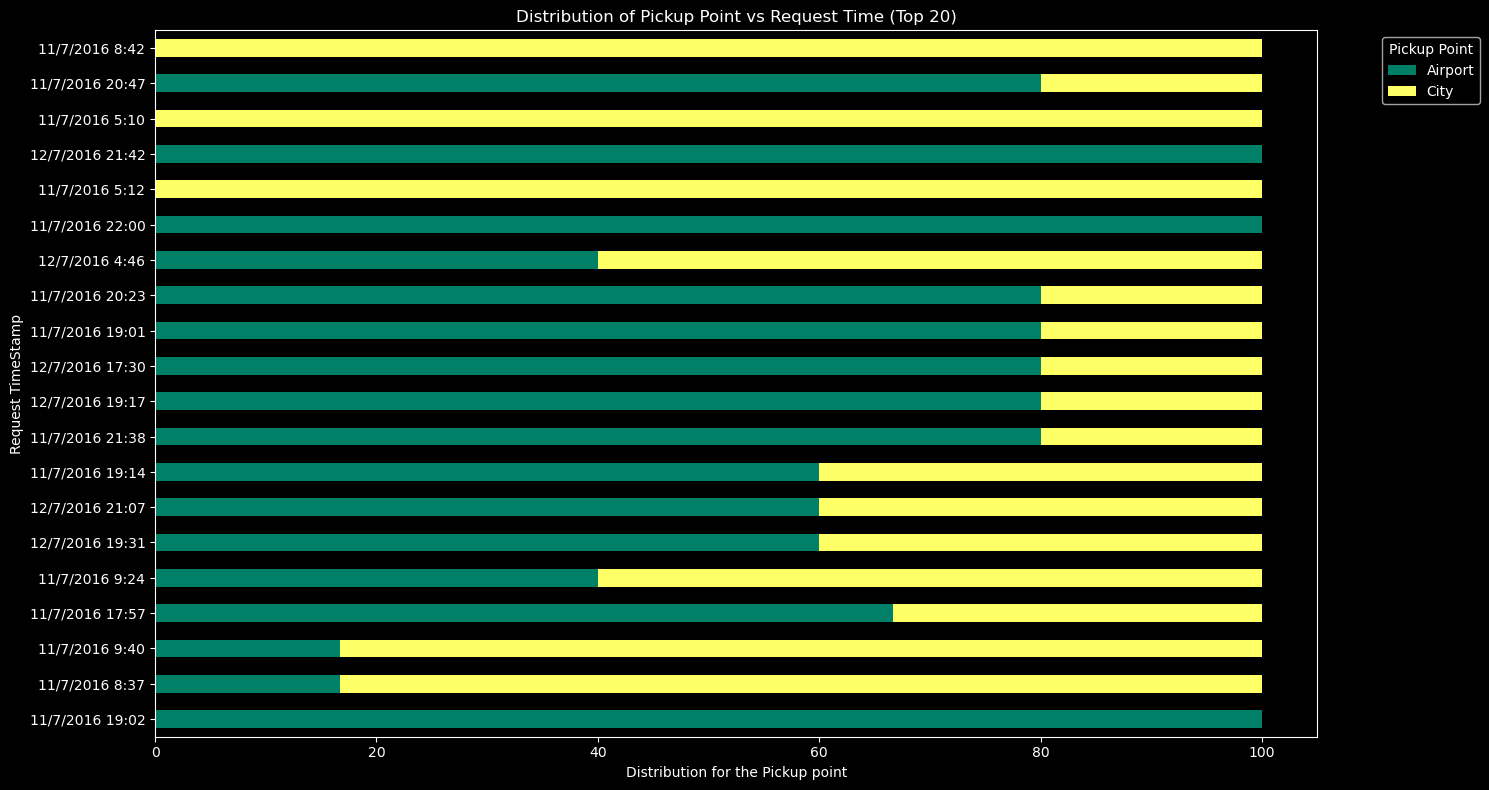

In [100]:
# Chart - 8 visualization code
P_1 = md.groupby(["Request timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
P_11 = P_1.div(P_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_P = P_1.sum(axis=1).sort_values(ascending=False).head(20).index
P_top20 = P_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
P_top20.plot(kind="barh", stacked=True, colormap="summer", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Pickup Point vs Request Time (Top 20)")
plt.legend(title="Pickup Point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest distribution for airport pickup point is for the request timestamps 19:02, 22:00 and 21:42 with common date as 11/7/2016.
2) The highest distribution for city pickup point is for the request timestamps 5:12, 5:10 and 8:42 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the customers are preferring city commute mostly in the morning time and airport commute in the evening/ night time.

#### Chart - 9

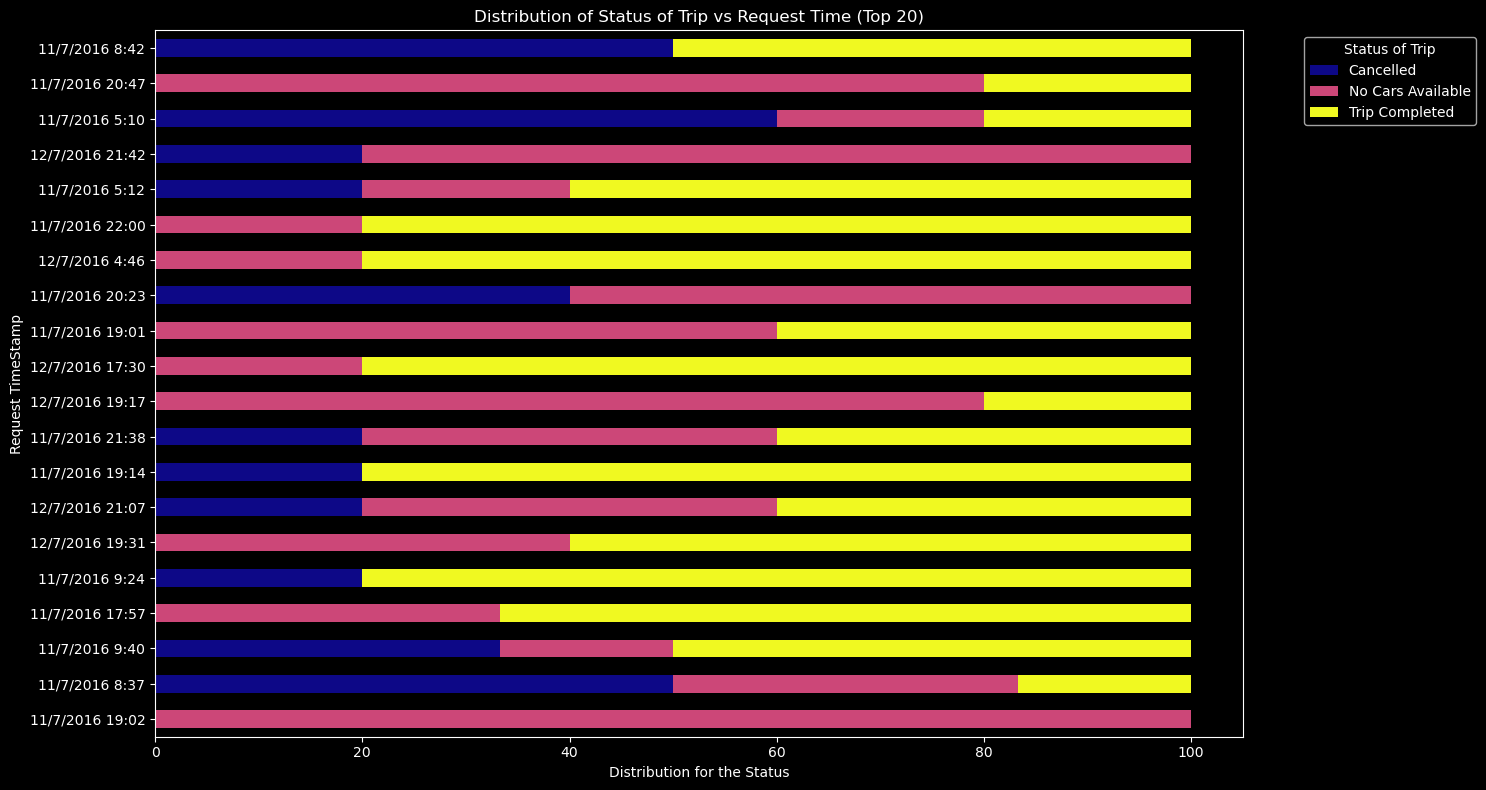

In [96]:
# Chart - 9 visualization code
S_1 = md.groupby(["Request timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
S_11 = S_1.div(S_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_S = S_1.sum(axis=1).sort_values(ascending=False).head(20).index
S_top20 = S_11.loc[top_S]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
S_top20.plot(kind="barh", stacked=True, colormap="plasma", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Status")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Status of Trip vs Request Time (Top 20)")
plt.legend(title="Status of Trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for no cars available status is for the request timestamp 19:02 with common date as 11/7/2016.
2) The highest count for cancelled status is for the request timestamp 5:10 with common date as 11/7/2016.
3) The highest count for Trip Completed status is for the request timestamps 4:46, 9:24, 19:14, 17:30 and 22:00 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the no cars available status is mostly for evening/ night time, cancelled status is mostly for morning time and Trip completed status has equal no of count for both evening/ night and morning time.
As per this morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab service.

#### Chart - 10

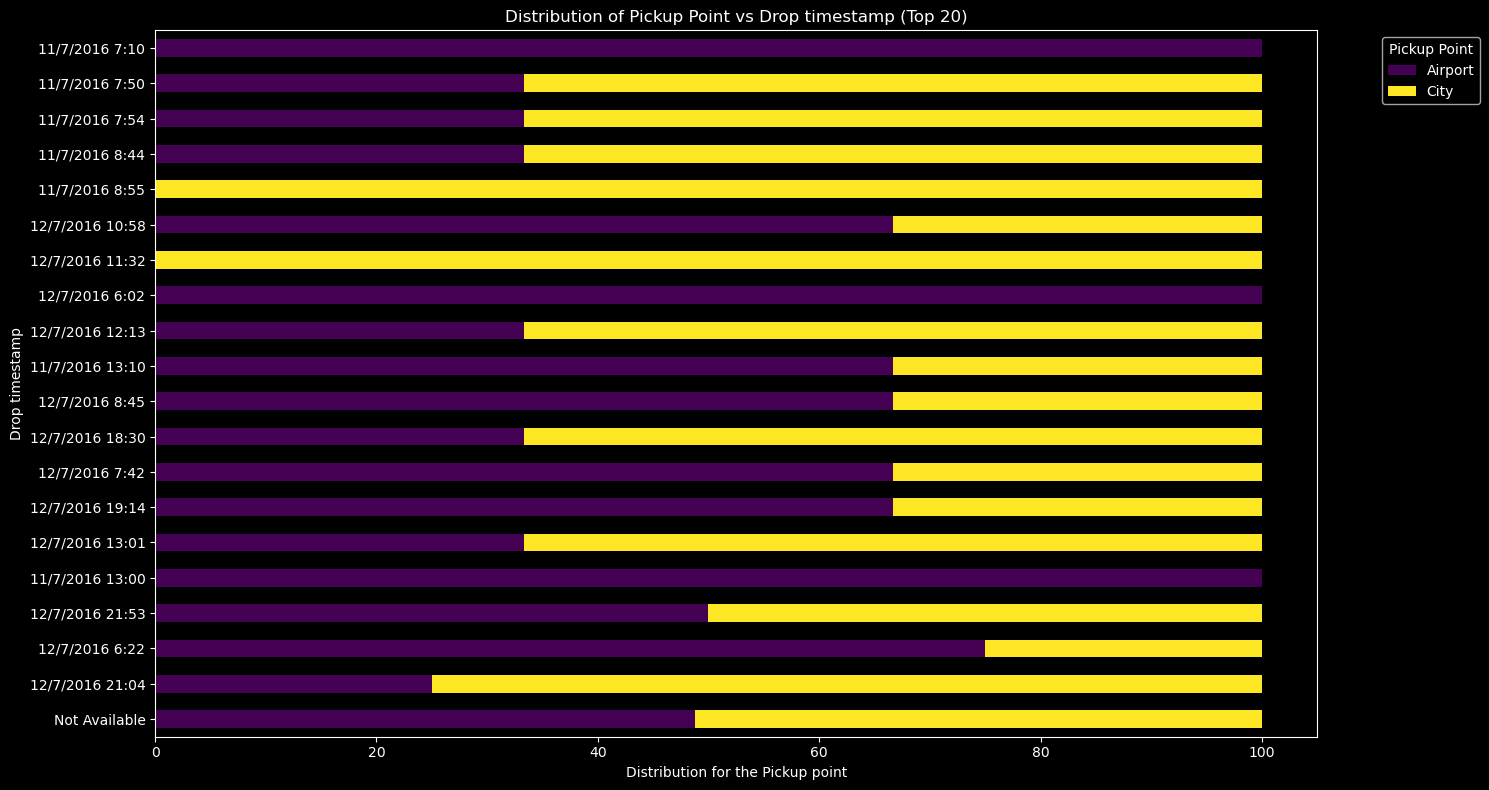

In [106]:
# Chart - 10 visualization code
Pd_1 = md.groupby(["Drop timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Pd_11 = Pd_1.div(Pd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Pd = Pd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Pd_top20 = Pd_11.loc[top_Pd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Pd_top20.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Drop timestamp")
plt.title("Distribution of Pickup Point vs Drop timestamp (Top 20)")
plt.legend(title="Pickup Point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for airport pickup point is for the drop timestamps 13:00, 6:02 and 7:10 with common date as 11/7/2016.
2) The highest count for city pickup point is for the drop timestamps 8:55 and 11:32 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the airport and city pickup point both have high count for morning/ afternoon drop timestamps, which means customers are reaching their destination/ arrivals in the morning/ afternoon time. Remembering this drivers should be informed that not to cancel morning requests as it will impact company profits. 

#### Chart - 11

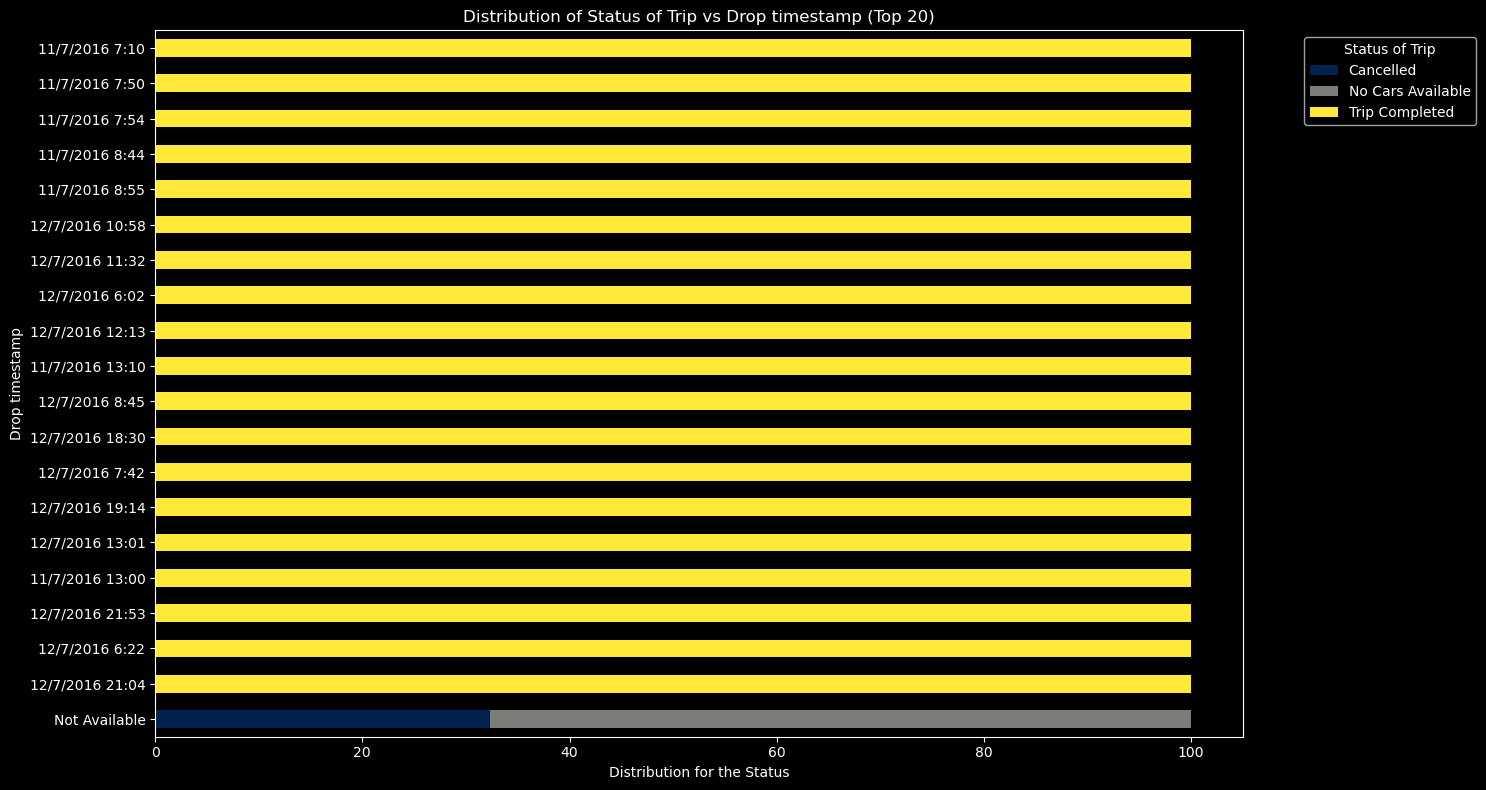

In [102]:
# Chart - 11 visualization code
Sd_1 = md.groupby(["Drop timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Sd_11 = Sd_1.div(Sd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Sd = Sd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Sd_top20 = Sd_11.loc[top_Sd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Sd_top20.plot(kind="barh", stacked=True, colormap="cividis", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Status")
plt.ylabel("Drop timestamp")
plt.title("Distribution of Status of Trip vs Drop timestamp (Top 20)")
plt.legend(title="Status of Trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for no cars available status is for the morning drop timestamp with common date as 11/7/2016.
2) The highest count for cancelled status is for the morning drop timestamp with common date as 11/7/2016.
3) The highest count for Trip Completed status is for the drop timestamps 7:10, 7:50, 7:54, 8:44, 8:55, 10:58, 11:32, 6:02, 12:13 and 13:10 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the drop time is morning for all three status which means cancelled trips are mostly done in the morning which affects the business as most customers are travelling in the morning, the company should inform the drivers that if they cancel trips in morning than they have to face penalty as this will reduce cancellation and ultimately increase profits for the company.

#### Chart - 12

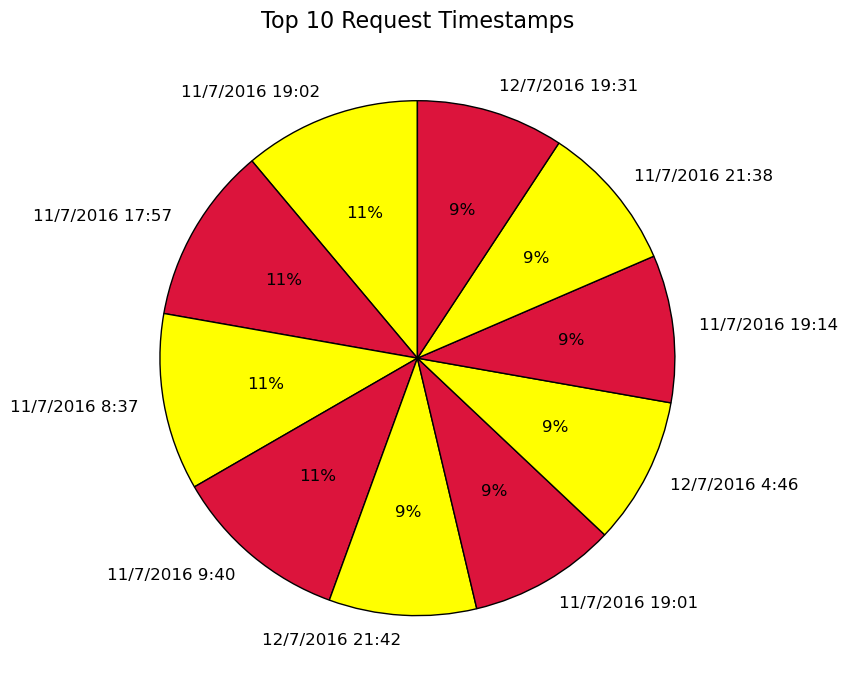

In [110]:
# Chart - 12 visualization code
co = md['Request timestamp'].value_counts().head(10)

# No conversion to int here
plt.figure(figsize=(15, 7))
co.plot(
    kind='pie',
    labels=co.index,  # keep as strings
    autopct=lambda p: '{:.0f}%'.format(p),
    colors=['yellow', 'crimson'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 12, 'color': 'black'}
)

plt.title('Top 10 Request Timestamps', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above pie chart gives clear distribution of request timestamps and help us to compare each of them with each other easily.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above pie chart:-

1) The highest distribution is for the request time stamps 19:02, 17:57, 8:37 and 9:40 with 11% value each.
2) The lowest distribution is for the request time stamps 19:31, 21:38, 19:14, 4:46 , 21:42 and 19:01 with 9% value each.  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the request time count is almost same for both morning/ afternoon and evening/ night time.

#### Chart - 13

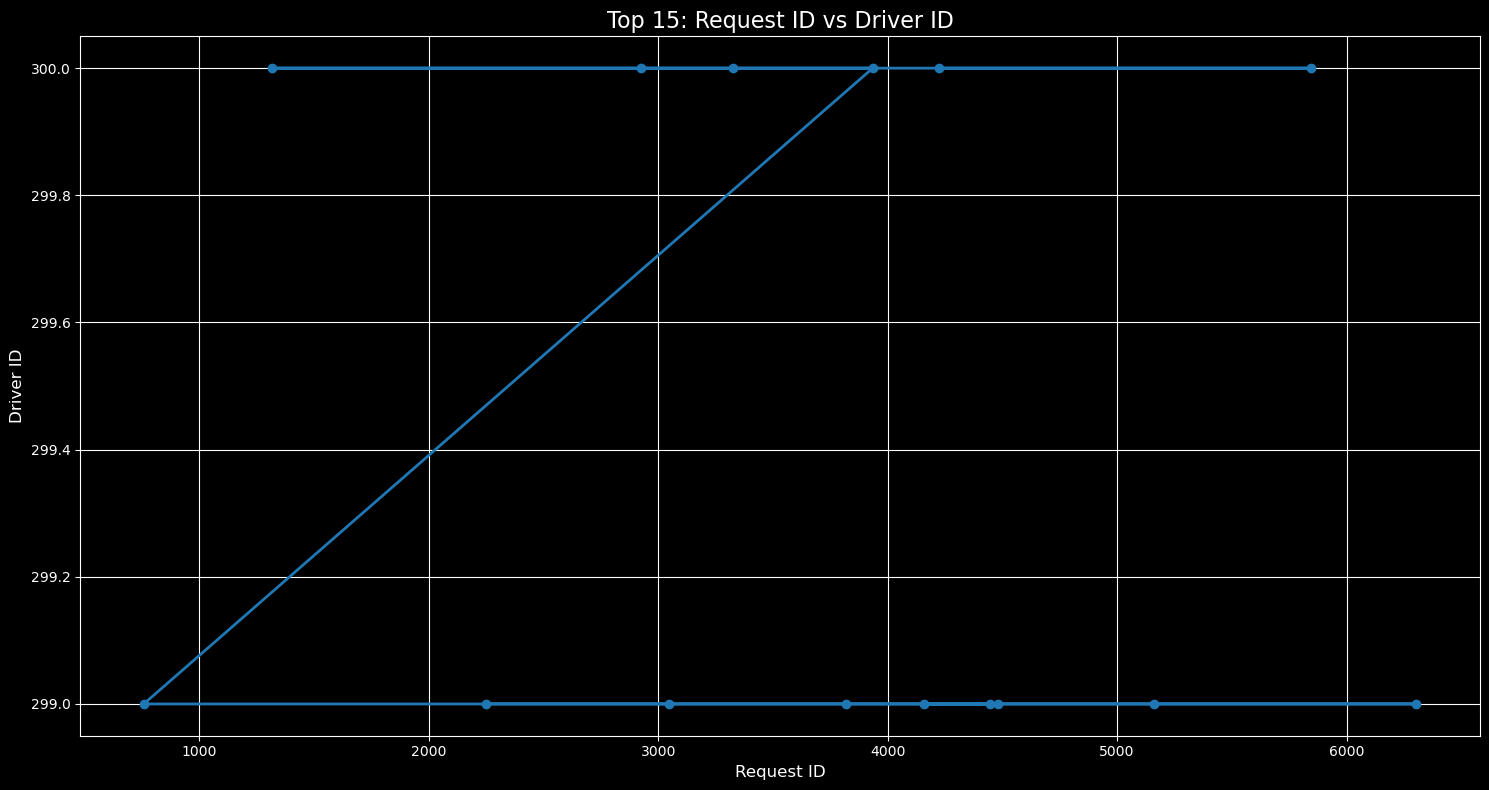

In [114]:
# Chart - 13 visualization code

plt.style.use('dark_background')

# Clean column names
md.columns = md.columns.str.strip()

# Optional: Convert columns to numeric (in case they're strings)
md['Driver id'] = pd.to_numeric(md['Driver id'], errors='coerce')
md['Request id'] = pd.to_numeric(md['Request id'], errors='coerce')

# Drop rows with missing values
md = md.dropna(subset=['Driver id', 'Request id'])

# Sort by Driver id descending and take top 15
top_rd = md[['Request id', 'Driver id']].sort_values(by='Driver id', ascending=False).head(15)

# Plot
plt.figure(figsize=(15, 8))
plt.plot(top_rd['Request id'], top_rd['Driver id'], marker="o", color='tab:blue', linestyle='-', linewidth=2)

plt.xlabel("Request ID", fontsize=12)
plt.ylabel("Driver ID", fontsize=12)
plt.title("Top 15: Request ID vs Driver ID", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above line chart is best for analyzing trends over a period of time for numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above line chart:-

1) For top 15 values the above line chart shows a steady Z pattern over a specific period of time.
2) Mostly the cab service request is handled by driver id's 299 and 300.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the driver id 299 and 300 are getting maximum business and also they are completing their business services successfully.

#### Chart - 14 - Correlation Heatmap

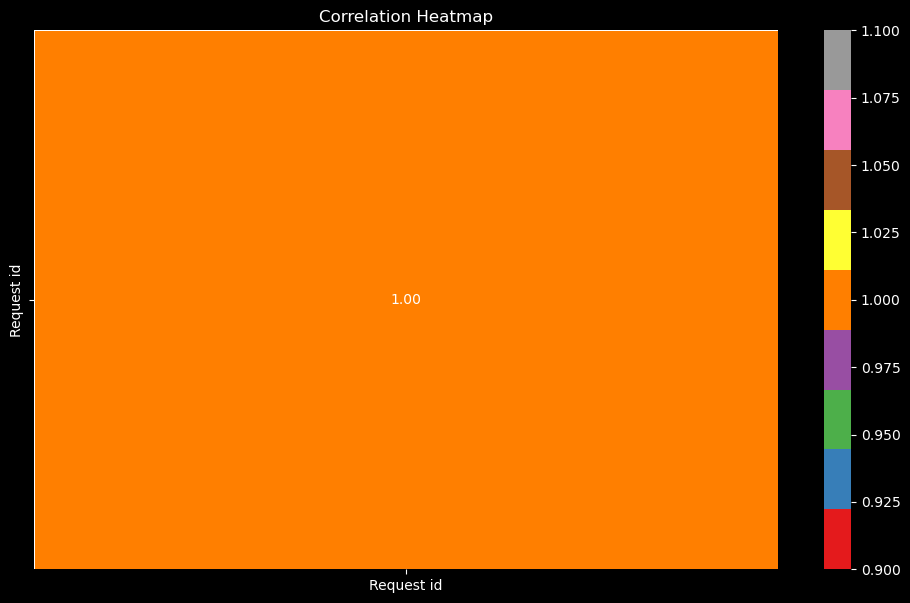

In [58]:
# Correlation Heatmap visualization code
plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical.corr().fillna(0)  
plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix, annot=True, cmap="Set1", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

The above heatmap is good for analyzing the coorelation between various numerical values with each other and itself.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above heatmap:-

1) As there is only one numerical variable which is request id so therefore it has coorelation as 1 with itself.

#### Chart - 15 - Pair Plot

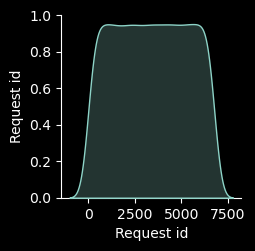

In [60]:
# Pair Plot visualization code
plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])
numerical = numerical.dropna(axis=1, thresh=len(numerical) * 0.8) 
sns.pairplot(numerical, diag_kind='kde', plot_kws={'alpha': 0.5})  
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot are best for comparing numerical variables with each other and itself to find trends, patterns and conclusions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above pair plot:-

1) As there is only numerical variable which is request id so thats why it shows steady increasing growth and steady decreasing growth as per dataset size which is totally natural visualization when one numerical variable is compared with itself.

### Power-BI Brief Analysis

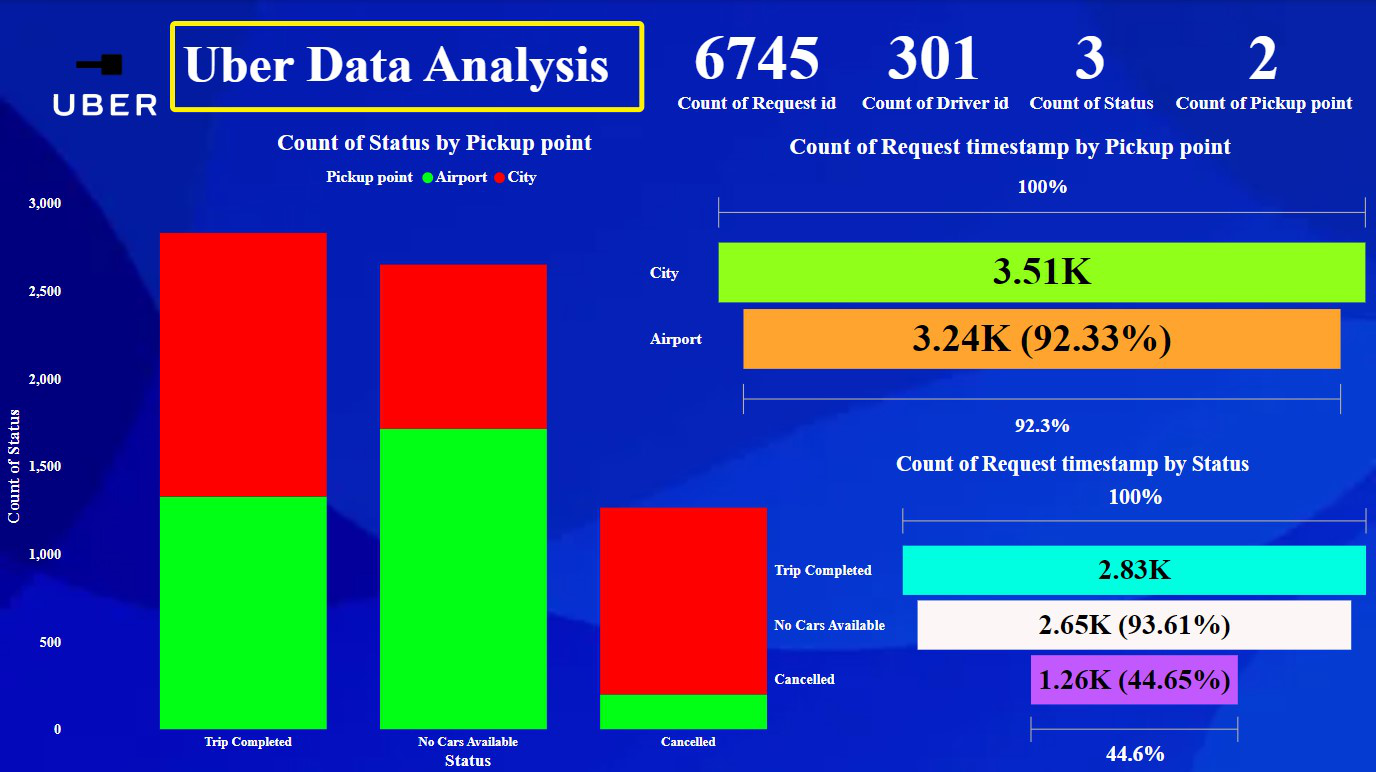

In [1]:
from PIL import Image
import IPython.display as display

image_path = "C:\\Users\\hp\\Desktop\\Exam Docs\\Labmentix Data analytics intern\\Week 16\\powerbi_1.jpg"

# Change this to your actual image path
image = Image.open(image_path)

display.display(image)  
# Show image in Jupyter

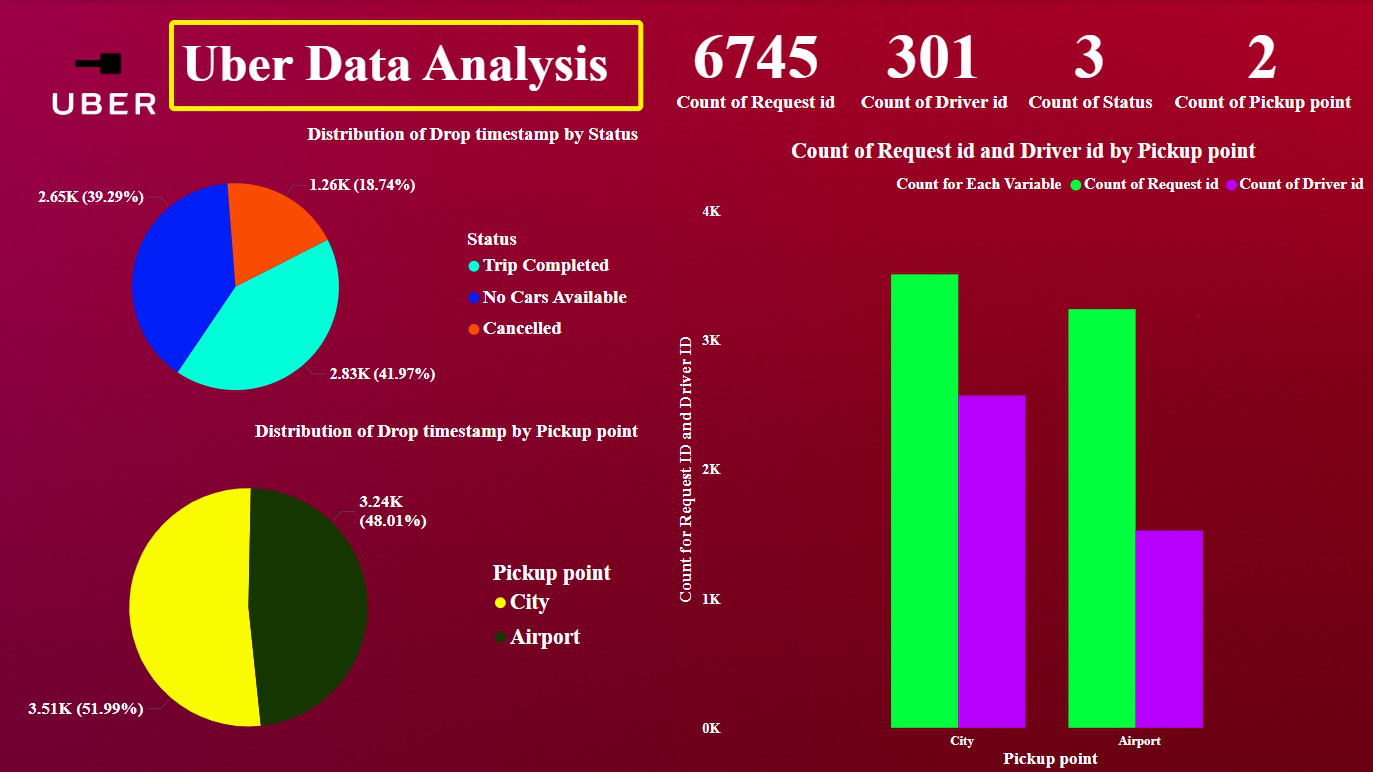

In [3]:
from PIL import Image
import IPython.display as display

image_path = "C:\\Users\\hp\\Desktop\\Exam Docs\\Labmentix Data analytics intern\\Week 16\\powerbi_2.jpg"

# Change this to your actual image path
image = Image.open(image_path)

display.display(image)  
# Show image in Jupyter

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**The Following are the suggestions which can be helpful to achieve business objective:-**

1) Maximum cars have completed their trip but almost equal no of cars have not completed trip as they were not available at that moment, which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profits for the organisation.
2) People often prefer Uber services inside city commute rather than airport commute which means company can do campaigns and offer some discounts on premium uber black service if customer books it from airport to ultimately increase profits for the company.
3) Almost equal number of count is their for trip completion status for both pickup point which is great positive sign but, company can improve a little bit for airport pickup point to increase overall cuatomer satisfaction and profits.
4) As we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.
5) Maximum cars are not available at airport pickup point where the most of the business comes for any cab service company, so if uber wants to increase its profits it should provide more number of cars at airport so as to not miss the opportunity of earn and retain frequent flyers who commute through airport and use cab services.
6) No cars available status is mostly for evening/ night time, cancelled status is mostly for morning time and Trip completed status has equal no of count for both evening/ night and morning time. As per this morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab service.
7) Airport and city pickup point both have high count for morning/ afternoon drop timestamps, which means customers are reaching their destination/ arrivals in the morning/ afternoon time. Remembering this drivers should be informed that not to cancel morning requests as it will impact company profits.
8) The drop time is morning for all three status which means cancelled trips are mostly done in the morning which affects the business as most customers are travelling in the morning, the company should inform the drivers that if they cancel trips in morning than they have to face penalty as this will reduce cancellation and ultimately increase profits for the company.

The above are some important suggestions that can solve business problems and also these can increase profits for the company in the near future.

# **Conclusion**

**The Following are the concluding points for the above data analysis:-**

1) The dataset contains 6 columns and 6745 rows.
2) There are no duplicate values in the dataset.
3) There are total 2 columns drop timestamps and driver id having missing values which we then later on replaced with Not Available value.
4) Highest count is for Trip completed status which is 2831, second highest count is for No Cars Available status which is 2650 and lowest count is for Cancelled status which is 1264.
5) Highest count is for city pickup point which is 3507 and lowest count is for airport pickup point which is 3238.
6) For trip completed status the highest count is for city which is 1504 and lowest count is for airport which is 1327.
7) For Cancelled Trips status the highest count is for city which is 1066 and lowest count is for airport which is 198.
8) For no cars available status the highest count is for airport which is 1713 and lowest count is for city which is 937.
9) Mostly the cab service request is handled by driver id's 299 and 300.
10) As there is only one numerical variable which is request id so therefore it has coorelation as 1 with itself.

The above are the concluding points for the above EDA data analysis for the Uber demand supply gap dataset.